# Unit-aware computations with ``brainunit``

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaobrain/brainx/blob/main/docs/basics/brainunit_unit_aware_computations.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/chaobrain/brainx/blob/main/docs/basics/brainunit_unit_aware_computations.ipynb)

## What is ``brainunit``?

``brainunit`` is the physical-units and unit-aware mathematics package in the BrainX ecosystem. It lets numerical values carry explicit units such as milliseconds, millivolts, amperes, siemens, and farads, then checks dimensional consistency as those quantities are converted, combined, and passed through mathematical operations.

It is used to make computational neuroscience and brain-modeling code more readable and less error-prone: model parameters, simulation time steps, currents, voltages, conductances, and array computations can keep their physical meaning while still working with JAX/NumPy-style workflows. In practice, ``brainunit`` helps catch unit mistakes early, handles compatible conversions, and keeps equations close to the way they are written in papers.

For complete API details, supported units, and advanced examples, see the [brainunit documentation](https://brainx.chaobrain.com/brainunit/).

## Why Physical Units?

**Brain models involve many physical quantities:**
- Time (milliseconds, seconds)
- Voltage (millivolts)
- Current (nanoamperes, microamperes)
- Conductance (nanosiemens, microsiemens)
- Capacitance (picofarads)
- Resistance (megaohms)

**Problems without unit tracking:**
- Mixing incompatible units (adding voltage and current)
- Forgetting to convert units (using seconds instead of milliseconds)
- Hard-to-debug errors from dimensionally incorrect equations

**Benefits of ``brainunit``:**
- Automatic dimension checking prevents errors
- Clear, self-documenting code
- Seamless unit conversions
- JAX-compatible for GPU/TPU acceleration

In [32]:
# Imports
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

## Creating Quantities with Units

A **quantity** combines a numerical value with a physical unit.
In ``brainunit``, multiply values by unit constants:

In [33]:
# Time quantities
t1 = 10.0 * u.ms  # 10 milliseconds
t2 = 0.01 * u.second  # 0.01 seconds
t3 = 1.5 * u.us  # 1.5 microseconds

print("t1 =", t1)
print("t2 =", t2)
print("t3 =", t3)

t1 = 10. ms
t2 = 0.01 s
t3 = 1.5 us


In [34]:
# Voltage quantities
V_rest = -70.0 * u.mV
V_thresh = -50.0 * u.mV
V_spike = 40.0 * u.mV

print("\nNeuron voltages:")
print("V_rest =", V_rest)
print("V_thresh =", V_thresh)
print("V_spike =", V_spike)


Neuron voltages:
V_rest = -70. mV
V_thresh = -50. mV
V_spike = 40. mV


In [35]:
# Current and conductance
I_app = 200.0 * u.pA  # applied current in picoamperes
g_leak = 10.0 * u.nS  # leak conductance in nanosiemens
C_m = 100.0 * u.pF    # membrane capacitance in picofarads

print("\nCircuit parameters:")
print("I_app =", I_app)
print("g_leak =", g_leak)
print("C_m =", C_m)


Circuit parameters:
I_app = 200. pA
g_leak = 10. nS
C_m = 100. pF


### Common Units in Neuroscience

**Time:** `u.second`, `u.ms` (millisecond), `u.us` (microsecond)

**Voltage:** `u.volt`, `u.mV` (millivolt)

**Current:** `u.amp`, `u.mA` (milliampere), `u.uA` (microampere), `u.nA` (nanoampere), `u.pA` (picoampere)

**Conductance:** `u.siemens`, `u.mS` (millisiemens), `u.uS` (microsiemens), `u.nS` (nanosiemens)

**Capacitance:** `u.farad`, `u.uF` (microfarad), `u.nF` (nanofarad), `u.pF` (picofarad)

**Resistance:** `u.ohm`, `u.kohm` (kiloohm), `u.Mohm` (megaohm)

**Frequency:** `u.Hz` (hertz), `u.kHz` (kilohertz)

## Unit Arithmetic

``brainunit`` automatically checks dimensional consistency and propagates units through calculations.

In [36]:
# Addition and subtraction: units must match
V1 = -70.0 * u.mV
V2 = -50.0 * u.mV
delta_V = V2 - V1
print("delta_V =", delta_V)  # 20.0 mV


delta_V = 20. mV


In [37]:

# Multiplication and division: units combine
I = 100.0 * u.pA
R = 200.0 * u.Mohm
V = I * R
print("\nV = I * R =", V)  # Voltage in appropriate units



V = I * R = 20000. uV


In [38]:

# Division produces new units
g = I / V1  # conductance = current / voltage
print("g = I / V =", g)

g = I / V = -1.4285715 nS


In [39]:
# Time constant: tau = R * C
R_m = 100.0 * u.Mohm
C_m = 100.0 * u.pF
tau_m = R_m * C_m
print("\ntau_m = R_m * C_m =", tau_m)


tau_m = R_m * C_m = 10000. us


### Automatic Dimension Checking

``brainunit`` prevents dimensionally incorrect operations:

In [40]:
# This will work: same dimensions
V_total = (-70.0 * u.mV) + (20.0 * u.mV)
print("Valid: V_total =", V_total)

Valid: V_total = -50. mV


In [41]:
# This will raise an error: incompatible dimensions
try:
    bad_sum = (100.0 * u.mV) + (50.0 * u.ms)  # voltage + time!
except Exception as e:
    print("\nError caught:", type(e).__name__)
    print("Message:", str(e)[:100], "...")


Error caught: UnitMismatchError
Message: Cannot calculate 
100. mV + 50. ms, because units do not match: mV != ms ...


In [42]:
# This will also raise an error: incompatible units
try:
    bad_sum2 = (10.0 * u.mV) + (5.0 * u.mA)  # voltage + current!
except Exception as e:
    print("\nError caught:", type(e).__name__)
    print("Message:", str(e)[:100], "...")


Error caught: UnitMismatchError
Message: Cannot calculate 
10. mV + 5. mA, because units do not match: mV != mA ...


## Unit Conversions

Convert quantities between compatible units using ``.to()`` method:

In [43]:
# Time conversions
t_ms = 100.0 * u.ms
t_s = t_ms.to(u.second)
t_us = t_ms.to(u.us)

print("Time conversions:")
print(f"  {t_ms} = {t_s} = {t_us}")

Time conversions:
  100. ms = 0.1 s = 100000. us


In [44]:
# Voltage conversions
V_mv = -70.0 * u.mV
V_v = V_mv.to(u.volt)

print("\nVoltage conversions:")
print(f"  {V_mv} = {V_v}")


Voltage conversions:
  -70. mV = -0.07 V


In [45]:
# Current conversions
I_pa = 200.0 * u.pA
I_na = I_pa.to(u.nA)
I_ua = I_pa.to(u.uA)

print("\nCurrent conversions:")
print(f"  {I_pa} = {I_na} = {I_ua}")


Current conversions:
  200. pA = 0.2 nA = 0.0002 uA


In [46]:
# Automatic conversion in compatible operations
t1 = 10.0 * u.ms
t2 = 0.01 * u.second
t_sum = t1 + t2  # automatically handles different units
print("\nAutomatic conversion:")
print(f"  {t1} + {t2} = {t_sum}")


Automatic conversion:
  10. ms + 0.01 s = 20. ms


## Working with Arrays

``brainunit`` seamlessly works with NumPy and JAX arrays:

In [47]:
# Create array quantities
voltages = np.array([-70.0, -60.0, -50.0, -40.0, -30.0]) * u.mV
print("Voltages array:", voltages)
print("Shape:", voltages.shape)
print("Unit:", voltages.unit)

Voltages array: [-70. -60. -50. -40. -30.] mV
Shape: (5,)
Unit: mV


In [48]:
# Array operations preserve units
V_mean = u.math.mean(voltages)
V_std = u.math.std(voltages)
print("\nStatistics:")
print("  Mean:", V_mean)
print("  Std:", V_std)


Statistics:
  Mean: -50. mV
  Std: 14.142136 mV


In [49]:
# Element-wise operations
V_shifted = voltages + 10.0 * u.mV
print("\nShifted voltages:", V_shifted)


Shifted voltages: [-60. -50. -40. -30. -20.] mV


In [50]:
# Time arrays for simulation
dt = 0.1 * u.ms
t_end = 100.0 * u.ms
n_steps = int(t_end / dt)
time = np.arange(n_steps) * dt
print("\nTime array:")
print("  Length:", len(time))
print("  First 5 points:", time[:5])
print("  Last point:", time[-1])


Time array:
  Length: 1000
  First 5 points: [0.  0.1 0.2 0.3 0.4] ms
  Last point: 99.9 ms


## Mathematical Functions

Use ``u.math`` when a mathematical operation should understand physical units. The most important rule is dimensional consistency:

- Functions such as ``exp()``, ``sin()``, and ``cos()`` require a dimensionless input, because their arguments represent pure numbers or phases.
- Ratios such as ``t / tau`` or ``frequency * time`` are dimensionless and are safe to pass into these functions.
- The result of these functions is dimensionless, so you can multiply it by a physical quantity afterward.
- Convert quantities to plain numbers only at boundaries such as plotting or formatted reporting.


Exponential decay:
  tau = 10. ms
  t/tau at the first point = 0.00
  t/tau at the last point = 5.00
  exp(-t/tau) at the last point = 0.0067


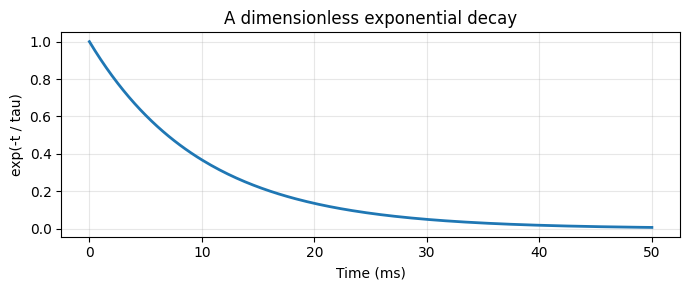

In [51]:
# Build a dimensionless argument before calling exp().
tau = 10.0 * u.ms
time = np.linspace(0.0, 50.0, 200) * u.ms
normalized_time = time / tau

decay = u.math.exp(-normalized_time)

print("Exponential decay:")
print(f"  tau = {tau}")
print(f"  t/tau at the first point = {normalized_time[0]:.2f}")
print(f"  t/tau at the last point = {normalized_time[-1]:.2f}")
print(f"  exp(-t/tau) at the last point = {decay[-1]:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(time.to(u.ms).magnitude, decay, linewidth=2)
plt.xlabel('Time (ms)')
plt.ylabel('exp(-t / tau)')
plt.title('A dimensionless exponential decay')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The dimensionless result can then scale a unitful quantity. This is common in neural models, where exponential factors describe how voltage, current, or conductance relaxes over time.


Voltage relaxation:
  Initial voltage = -50. mV
  Final voltage = -69.86524 mV


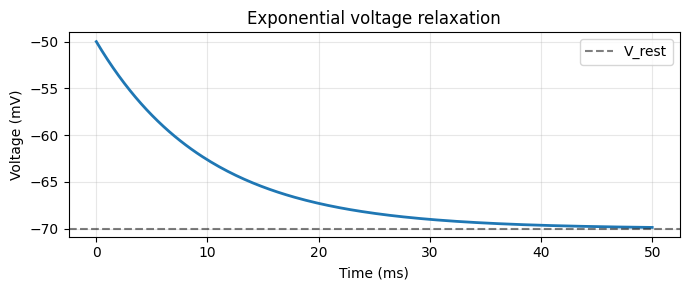

In [52]:
# Use the dimensionless decay factor to scale a voltage relaxation.
V_rest = -70.0 * u.mV
delta_V0 = 20.0 * u.mV
V_trace = V_rest + delta_V0 * decay

print("Voltage relaxation:")
print(f"  Initial voltage = {V_trace[0]}")
print(f"  Final voltage = {V_trace[-1]}")

plt.figure(figsize=(7, 3))
plt.plot(time.to(u.ms).magnitude, V_trace.to(u.mV).magnitude, linewidth=2)
plt.axhline(V_rest.to(u.mV).magnitude, ls='--', color='k', alpha=0.5, label='V_rest')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Exponential voltage relaxation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Sinusoidal current:
  frequency = 25. Hz
  amplitude = 100. pA
  phase at the last point = 18.85
  current range = -99.999504 pA to 99.999504 pA


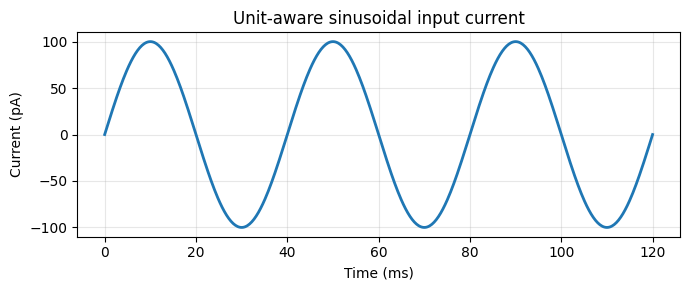

In [53]:
# Trigonometric functions also need a dimensionless phase.
frequency = 25.0 * u.Hz
amplitude = 100.0 * u.pA
time = np.linspace(0.0, 120.0, 500) * u.ms
phase = 2 * np.pi * frequency * time
current = amplitude * u.math.sin(phase)

print("Sinusoidal current:")
print(f"  frequency = {frequency}")
print(f"  amplitude = {amplitude}")
print(f"  phase at the last point = {phase[-1]:.2f}")
print(f"  current range = {u.math.min(current)} to {u.math.max(current)}")

plt.figure(figsize=(7, 3))
plt.plot(time.to(u.ms).magnitude, current.to(u.pA).magnitude, linewidth=2)
plt.xlabel('Time (ms)')
plt.ylabel('Current (pA)')
plt.title('Unit-aware sinusoidal input current')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [54]:
# Always normalize unitful quantities before using exp(), sin(), or cos().
# For example, use time / tau rather than time itself.
tau = 20.0 * u.ms
normalized_time = time / tau
safe_decay = u.math.exp(-normalized_time)

print("Safe dimensionless exponential:")
print(f"  tau = {tau}")
print(f"  normalized_time[:3] = {normalized_time[:3]}")
print(f"  exp(-time / tau)[:3] = {safe_decay[:3]}")


Safe dimensionless exponential:
  tau = 20. ms
  normalized_time[:3] = [0.         0.01202405 0.0240481 ]
  exp(-time / tau)[:3] = [1.         0.98804795 0.97623876]


## Practical Example: RC Circuit Dynamics

Let's model a simple RC circuit representing a passive neuron membrane.

The membrane voltage follows:
$\tau_m \frac{dV}{dt} = -(V - V_{rest}) + R_m I_{app}$

where:
- $\tau_m = R_m C_m$ is the membrane time constant
- $R_m$ is membrane resistance
- $C_m$ is membrane capacitance
- $I_{app}$ is applied current

In [55]:
# Membrane parameters
R_m = 100.0 * u.Mohm
C_m = 100.0 * u.pF
tau_m = R_m * C_m
V_rest = -70.0 * u.mV

print("Membrane parameters:")
print(f"  R_m = {R_m}")
print(f"  C_m = {C_m}")
print(f"  tau_m = {tau_m.to(u.ms)}")
print(f"  V_rest = {V_rest}")

Membrane parameters:
  R_m = 100. Mohm
  C_m = 100. pF
  tau_m = 10. ms
  V_rest = -70. mV


In [56]:
# Simulation parameters
dt = 0.1 * u.ms
t_end = 50.0 * u.ms
n_steps = int(t_end / dt)
time = np.arange(n_steps) * dt

# Applied current (step input)
I_app = np.zeros(n_steps) * u.pA
I_start = int(5.0 * u.ms / dt)
I_end = int(35.0 * u.ms / dt)
I_app[I_start:I_end] = 150.0 * u.pA

# Integrate membrane voltage using exponential Euler
V = np.zeros(n_steps) * u.mV
V[0] = V_rest

for i in range(n_steps - 1):
    # Steady-state voltage for current input
    V_inf = V_rest + R_m * I_app[i]
    # Exponential Euler step
    V[i + 1] = V_inf + (V[i] - V_inf) * u.math.exp(-dt / tau_m)

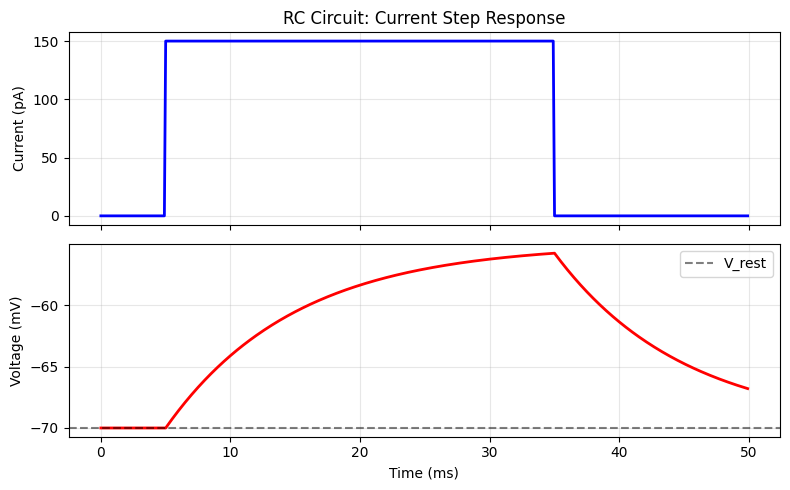

In [57]:
# Plot results
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(time, I_app.to(u.pA), 'b', linewidth=2)
axes[0].set_ylabel('Current (pA)')
axes[0].set_title('RC Circuit: Current Step Response')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, V, 'r', linewidth=2)
axes[1].axhline(V_rest.to(u.mV).magnitude, ls='--', color='k', alpha=0.5, label='V_rest')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Voltage (mV)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
# Verify the steady-state response
V_ss_expected = V_rest + R_m * 150.0 * u.pA
V_ss_observed = u.math.max(V)
print(f"\nSteady-state voltage:")
print(f"  Expected: {V_ss_expected}")
print(f"  Observed: {V_ss_observed}")
print(f"  Match: {u.math.allclose(V_ss_expected, V_ss_observed, atol=0.01 *u.mV)}")


Steady-state voltage:
  Expected: -55. mV
  Observed: -55.746826 mV
  Match: False


## Working with Dimensionless Quantities

Many model equations create dimensionless values by dividing compatible units. In current `brainunit` behavior, when all dimensions cancel exactly, the result may already be a plain Python/JAX/NumPy scalar or array rather than a `Quantity` object.

Use `.to_decimal(unit)` when a value still carries physical units and you want to pass a plain number to plotting, serialization, formatted text, or another library. If a ratio is already dimensionless and already returned as a plain number, use it directly.

The helper below keeps tutorial code robust at this boundary: it calls `.to_decimal()` for `Quantity` objects and leaves already-plain numeric values unchanged.

In [59]:
def as_decimal(value, unit=None):
    """Return a plain numeric value from either a Quantity or an already numeric value."""
    if hasattr(value, "to_decimal"):
        return value.to_decimal(unit) if unit is not None else value.to_decimal()
    return value


# Compatible quantities can be converted explicitly before leaving unit-aware code.
V1 = -50.0 * u.mV
V2 = -70.0 * u.mV
V1_mV = V1.to_decimal(u.mV)
V2_mV = V2.to_decimal(u.mV)

# The ratio is dimensionless. In current brainunit versions, this is already a float.
voltage_ratio = V1 / V2
voltage_ratio_decimal = as_decimal(voltage_ratio)

print("Voltage values converted with to_decimal(unit):")
print(f"  V1 = {V1_mV:.1f} mV")
print(f"  V2 = {V2_mV:.1f} mV")
print("Dimensionless ratio:")
print(f"  V1 / V2 = {voltage_ratio_decimal:.4f}")
print(f"  ratio type = {type(voltage_ratio_decimal)}")

Voltage values converted with to_decimal(unit):
  V1 = -50.0 mV
  V2 = -70.0 mV
Dimensionless ratio:
  V1 / V2 = 0.7143
  ratio type = <class 'float'>


`.to_decimal(unit)` is also the clean way to prepare arrays for plotting or external libraries. Keep units during computation, then choose the display unit at the boundary.

In the example below, `time` and `V_trace` remain unit-aware in the model equation, but the plotted arrays are converted to milliseconds and millivolts as plain numerical values. The normalized time is dimensionless, so it is converted through `as_decimal()` only if it still has `brainunit` metadata.

Boundary conversion with to_decimal(unit):
  normalized_time[0] = 0.00
  time_ms[:3]        = [0.         0.25062657 0.50125313]
  voltage_mV[:3]     = [-45.         -45.31132845 -45.61877989]


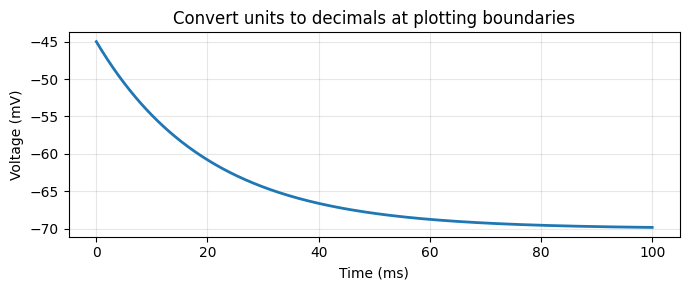

In [60]:
# Convert unitful quantities to plain numeric arrays only at the boundary.
tau = 20.0 * u.ms
time = np.linspace(0.0, 100.0, 400) * u.ms
normalized_time = time / tau
relaxation = u.math.exp(-normalized_time)

V_rest = -70.0 * u.mV
V0 = -45.0 * u.mV
V_trace = V_rest + (V0 - V_rest) * relaxation

time_ms = time.to_decimal(u.ms)
voltage_mV = V_trace.to_decimal(u.mV)
normalized_time_first = as_decimal(normalized_time[0])

print("Boundary conversion with to_decimal(unit):")
print(f"  normalized_time[0] = {normalized_time_first:.2f}")
print(f"  time_ms[:3]        = {time_ms[:3]}")
print(f"  voltage_mV[:3]     = {voltage_mV[:3]}")

plt.figure(figsize=(7, 3))
plt.plot(time_ms, voltage_mV, linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Convert units to decimals at plotting boundaries")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Another common dimensionless result is a relative or percent error.
V_expected = -65.0 * u.mV
V_measured = -62.0 * u.mV
relative_error = (V_measured - V_expected) / V_expected
percent_error = relative_error * 100.0

relative_error_decimal = as_decimal(relative_error)
percent_error_decimal = as_decimal(percent_error)

print("Relative error:")
print(f"  relative_error = {relative_error_decimal:.4f}")
print(f"  percent_error  = {percent_error_decimal:.2f}%")
print(f"  value type     = {type(relative_error_decimal)}")

Relative error:
  relative_error = -0.0462
  percent_error  = -4.62%
  value type     = <class 'float'>


In [62]:
# Dimensionless quantities are valid inputs to unit-aware math functions.
# Convert them to plain numbers only when a boundary needs plain numeric values.
phase = 2.0 * np.pi * (10.0 * u.Hz) * (25.0 * u.ms)
phase_decimal = as_decimal(phase)
sine_value = u.math.sin(phase)

print("Dimensionless phase:")
print(f"  phase     = {phase_decimal:.4f}")
print(f"  sin(phase) = {sine_value:.4f}")
print(f"  phase type = {type(phase_decimal)}")

Dimensionless phase:
  phase     = 1.5708
  sin(phase) = 1.0000
  phase type = <class 'float'>
